<a href="https://colab.research.google.com/github/adarshmodh/Deep-Learning-Projects/blob/master/Pytorch_Interview_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup, Run this cell first!

In [1]:
!pip install torch
import torch
from typing import List, Tuple

# Question 1 - Tensor Mechanics
What's wrong with the following pieces of code, fix and please explain the reasoning to the interviewer

## 1A
Perform a basic conv followed by a relu and another conv.
What's wrong with the following code? Can you fix it?

In [3]:
x = torch.rand(3,1,3,3) # B,C,H,W
conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=1)
#B,6,3,3
conv2 = torch.nn.Conv2d(in_channels=6, out_channels=64, kernel_size=3)
#B,64,1,1

out = conv1(x)
out = torch.relu(out)
out = conv2(out)

## 1B
Swap dimensions and reshape.Why doesn't this work?

In [8]:
x = torch.rand(3,4,5)
print(x.shape)
x.transpose(1,2).reshape(15,4)
print(x.shape)

# answer = transpose and reshape are both not in-place operation

torch.Size([3, 4, 5])
torch.Size([3, 4, 5])


## 1C
We have a large vector of points in 3D (x,y,z) and want to project it to a 2D screen in image space (u,v).

The linear matrix equation is U = K * P * X
* where U the coordinates in image space, a Nx3 vector in homogenous coordinates (u,v,1). Simply ignore the last dimension if you are not familiar with homogenous coordinates.
* K is a 3x3 camera matrix
* P is a 3x4 projection matrix (it is a horizontal concat of a 3x3 rotation matrix R with a 3x1 translation vector T)
* X is a Nx4 vector point in 3d (again in homogenous coordinates) -> (x,y,z,1)

Can you correct all the errors in the following project_camera function? Hint: you don't need to understand the theory behind camera projections. You can solve this question entirely based on fixing the tensor dimensions.

In [12]:
def project_camera(X: torch.Tensor, R: torch.Tensor, T: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
  # Compute P = [R|T]
  # P = torch.stack(R,T) # this is wrong, stack means it will concatenate vertically, but we need horizontal concatenation -> torch.cat
  P = torch.cat([R,T], dim=1) # P should be 3x4

  # Compute U
  # U = K * P * X # this is wrong because of element wise multiplication, we need matrix multiplication
  M = K @ P  # 3x3 @ 3x4 = 3x4
  U = (M @ X.T).T # Project all points: X is (N, 4) so we use transpose (4,N), M @ X.T gives (3, N), then transpose back to (N, 3)


  # normalize U by dividing by the 3rd component
  norm_U = U/U[:,2:3] #U[:,2] has shape (N,) which will not broadcast elementwise - gives runtime error
  # norm_U = U/U[:,2].unqueeze(1) alternate correct way
  return norm_U

X = torch.rand(1000,4)
R = torch.rand(3,3)
T = torch.rand(3,1)
K = torch.rand(3,3)
result = project_camera(X,R,T,K)

print(result.shape)

torch.Size([1000, 3])


#Question 2 - Debug a neural *network*

## 2A. Debug the network

Our intern, Bob, decided to build a neural network to find the location of a circle in an image and output the color. However, the network does not train properly nor output the correct results. Please help the intern debug it!
You will be provided a dataset that generate images with a single circle
in them with a color that can be in set of (red,green,blue).

### Dataset
The CircleDataset generates blank canvases and draws a single circle with random radius, position and color. It also contains a visualization utility function to help visualize the dataset and predictions. For the purpose of this interview, you can safely assume this code is correct.

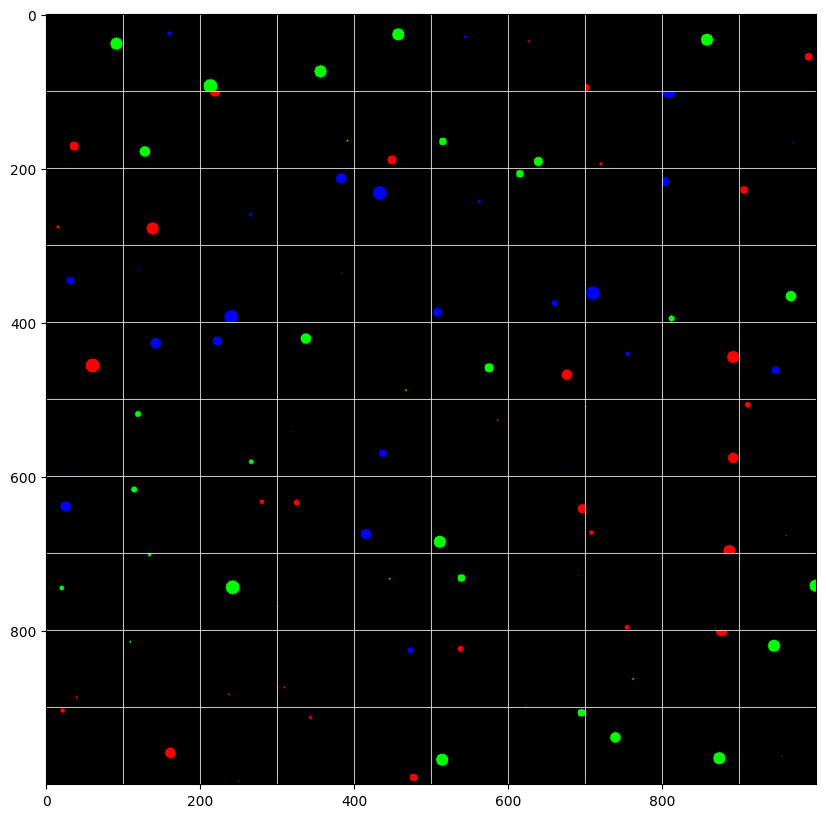

In [2]:
from torch.utils.data import Dataset
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2
%matplotlib inline

class CircleDataset(Dataset):
  """ This class can be used to generate blank canvases and draw a single
  circle with a random radius, position, and color in ranges defined by
  the user.
  """
  def __init__(self,
               size: int=100,
               min_radius: float=0.,
               max_radius: float=10.0,
               image_size_wh: List=[100,100],
               colors: List=[[255,0,0],[0,255,0],[0,0,255]]):
    self.size = size
    self.min_radius = min_radius
    self.max_radius = max_radius
    self.image_size_wh = image_size_wh
    self.color_map = colors
    self.gen = torch.Generator()
    self.gen.manual_seed(42)
    self.images, self.pos_labels, self.color_labels = self._generate_data()

  @staticmethod
  def generate_image_tensor(cx: float, cy: float, r:float,
                            img_w: int, img_h: int,
                            color: List[int],
                            fill: bool = True) -> torch.Tensor:
    blank_image = np.zeros((img_h,img_w,3), np.uint8)
    coords = (cx-r,cy-r,cx+r,cy+r)
    cv2.circle(blank_image, (int(cx), int(cy)), max(int(r),0), color, cv2.FILLED if fill else 3)
    img_arr = torch.from_numpy(blank_image.transpose((2, 0, 1))).type(torch.float)
    return img_arr

  def _generate_data(self) -> Tuple[List,List,List]:
    images, color_labels, pos_labels = [],[],[]
    w, h = self.image_size_wh
    for i in range(0, self.size):
      # select random parameters of the circle
      r = torch.rand(1,generator=self.gen).item() * (self.max_radius - self.min_radius) + self.min_radius
      cx = torch.rand(1,generator=self.gen).item() * w
      cy = torch.rand(1,generator=self.gen).item() * h
      color = torch.randint(0,len(self.color_map),(1,),generator=self.gen).item()
      img_tensor = CircleDataset.generate_image_tensor(cx,cy,r,w,h,self.color_map[color])
      images.append(img_tensor)
      pos_labels.append(torch.tensor([cx,cy,r], dtype=torch.float))
      color_labels.append(torch.tensor(color))
    return images, pos_labels, color_labels

  def __getitem__(self, idx: int) -> torch.Tensor:
    return self.images[idx], self.pos_labels[idx],  self.color_labels[idx]

  def __len__(self) -> int:
    return self.size

  def visualize_(self, cols: int=10, max_viz: int=100) -> None:
    # visualize only the first max_viz elements
    CircleDataset.visualize(self.images[0:max_viz], cols=cols)

  @staticmethod
  def create_image_grid(images: List[torch.Tensor], cols=10) -> torch.Tensor:
    assert len(images) > 0
    h, w = images[0].shape[1], images[0].shape[2]
    rows = math.ceil(len(images) / cols)
    image_grid = torch.zeros(3, rows * h , cols * w)
    # fill image_grid with images
    for i, img in enumerate(images):
      r_idx = (i // cols) * h
      c_idx = (i % cols) * w
      image_grid[:,r_idx:r_idx+h,c_idx:c_idx+w] = img
    # draw marker white lines to make visualization nicer
    for r in range(0,rows):
      image_grid[:,r*h,:] = 255
    for c in range(0,cols):
      image_grid[:,:,c*w] = 255
    return image_grid.permute(1,2,0).int()

  @staticmethod
  def visualize(gt_images: List[torch.Tensor],
                pred_images: List[torch.Tensor]=None,
                cols=10) -> None:
    """ Given a list of image (GT) tensors and prediction tensors,
    this helper function can visualize them in a grid pattern.
    """
    assert len(gt_images)>0
    if pred_images:
      assert len(gt_images) == len(pred_images)
    rows = math.ceil(len(gt_images) / cols)
    fig = plt.figure(figsize=[cols, rows])
    gt_grid = CircleDataset.create_image_grid(gt_images, cols)
    if not pred_images:
      plt.imshow(gt_grid)
    else:
      pred_grid = CircleDataset.create_image_grid(pred_images, cols)
      plt.imshow((gt_grid/1.5 + pred_grid).int())


test_dataset = CircleDataset(100,max_radius=10.)
test_dataset.visualize_()

### Model
The following code defines a simple model that can output a position, size, and color for a circle. You should *NOT* assume this code is correct.

In [3]:
import torch.nn as nn

class CircleRegressor(nn.Module):
  def __init__(self,
               input_size: int = 100,
               input_chans: int = 3,
               num_colors: int = 3):
    super(CircleRegressor, self).__init__()
    self.backbone = nn.Sequential(
        nn.Conv2d(input_chans, 16, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
        nn.ReLU(),
    )
    feature_size = 7**2 * 32
    # regress 1-hot encoding for color
    self.color_predictor = nn.Sequential(
        nn.Linear(feature_size, num_colors),
    )
    # regress 3 tuple - x0, y0, radius
    self.location_predictor = nn.Sequential(
        nn.Linear(feature_size, 3),
    )
    self.color_loss = nn.CrossEntropyLoss()
    self.loc_loss = nn.MSELoss()
    self.training = True

  def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    batch = x.shape[0]
    x = self.backbone(x)
    x = x.view(batch, -1) # give flattened output with batch size (B, C*H*W)

    # normalized outputs in [0,1] for x, y, radius
    location = torch.sigmoid(self.location_predictor(x))
    color_logits = self.color_predictor(x)
    return location, color_logits

  def predict(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    location, color_logits = self.forward(x)
    color_probs = torch.softmax(color_logits, dim=1)
    color_pred = color_probs.argmax(dim=1)
    return location, color_pred

  def compute_loss(self,
                   loc: torch.Tensor,
                   loc_label: torch.Tensor,
                   color: torch.Tensor,
                   color_label: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    loc_loss = self.loc_loss(loc, loc_label)
    color_loss = self.color_loss(color, color_label)
    return loc_loss, color_loss

def normalize_loc_labels(loc_label: torch.Tensor, h: int, w: int) -> torch.Tensor:
  """
  loc_label: (B, 3) in pixel units [x_center, y_center, radius]
  returns normalized labels in [0,1]
  """
  loc_label = loc_label.float().clone()
  loc_label[:, 0] = loc_label[:, 0] / w
  loc_label[:, 1] = loc_label[:, 1] / h
  loc_label[:, 2] = loc_label[:, 2] / min(w, h)
  return loc_label


def denormalize_loc_preds(loc_pred: torch.Tensor, h: int, w: int) -> torch.Tensor:
  """
  loc_pred: (B, 3) normalized in [0,1]
  returns pixel-space predictions [x_center, y_center, radius]
  """
  loc_pred = loc_pred.clone()
  loc_pred[:, 0] = loc_pred[:, 0] * w
  loc_pred[:, 1] = loc_pred[:, 1] * h
  loc_pred[:, 2] = loc_pred[:, 2] * min(w, h)
  return loc_pred


cr = CircleRegressor()

x = torch.rand(1, 3, 100, 100)
loc, color_logits = cr(x)

print("loc shape:", loc.shape)                  # (1, 3)
print("color logits shape:", color_logits.shape)  # (1, 3)

cr.eval()
with torch.no_grad():
    loc_pred, color_pred = cr.predict(x)

print("predicted loc:", loc_pred)
print("predicted color class:", color_pred)

loc shape: torch.Size([1, 3])
color logits shape: torch.Size([1, 3])
predicted loc: tensor([[0.4943, 0.5047, 0.5020]])
predicted color class: tensor([1])


### Training code
The following code is used to train and eval the provided model and dataset. After training for 10 epochs, Bob tries to visualize the eval outputs, the results show circle predictions that are almost always a single color and not well localized. The solid circles represent the ground truths and the circle outlines represent the predictions. Can you help Bob fix his model?


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch: 0, loss: 0.0853, loc_loss: 0.0797, color_loss: 0.0056
Epoch: 1, loss: 0.0656, loc_loss: 0.0639, color_loss: 0.0017
Epoch: 2, loss: 0.0586, loc_loss: 0.0440, color_loss: 0.0146
Epoch: 3, loss: 0.0209, loc_loss: 0.0193, color_loss: 0.0017
Epoch: 4, loss: 0.0088, loc_loss: 0.0084, color_loss: 0.0004
Epoch: 5, loss: 0.0081, loc_loss: 0.0066, color_loss: 0.0015
Epoch: 6, loss: 0.0105, loc_loss: 0.0083, color_loss: 0.0023
Epoch: 7, loss: 0.0129, loc_loss: 0.0071, color_loss: 0.0058
Epoch: 8, loss: 0.0051, loc_loss: 0.0046, color_loss: 0.0005
Epoch: 9, loss: 0.0051, loc_loss: 0.0046, color_loss: 0.0005
Training complete


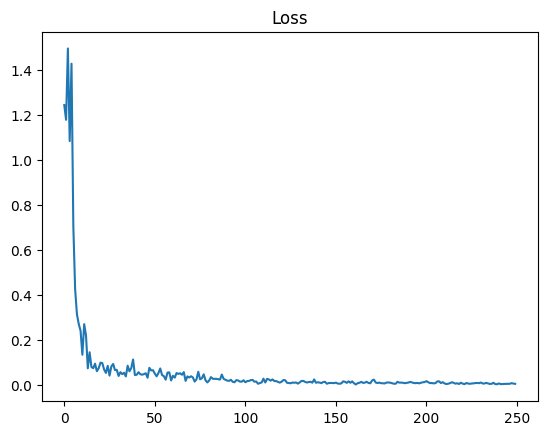

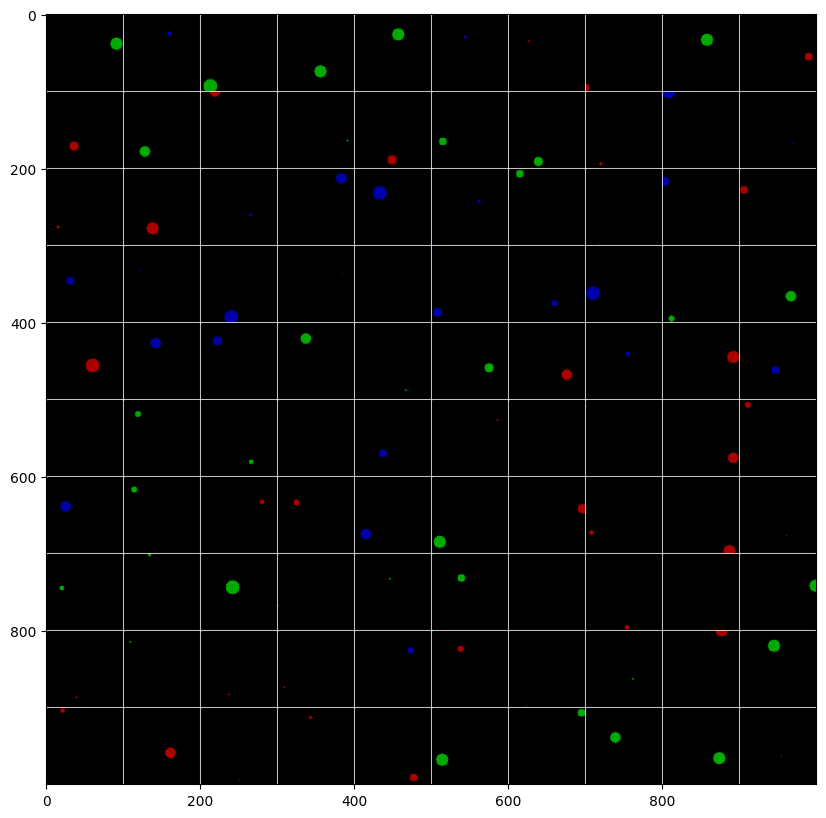

In [6]:
from torch.utils.data import DataLoader
import torch.optim as optim

def run_train(dataset: torch.utils.data.Dataset,
              model: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              num_epochs: int=10,
              batch_size: int=8,
              device: str = "cuda") -> None:
  train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=8)
  model.to(device)
  model.train()

  loss_arr = []
  for epoch in range(0, num_epochs):
    for i, (inputs, loc_label, color_label) in enumerate(train_loader):
      inputs = inputs.to(device).float()
      color_label = color_label.to(device).long()

      b, c, h, w = inputs.shape
      loc_label = normalize_loc_labels(loc_label, h, w).to(device)

      optimizer.zero_grad()
      location, color = model(inputs)
      # print(color, color_label)
      loc_loss, color_loss = model.compute_loss(location, loc_label, color, color_label)
      total_loss = loc_loss + color_loss
      total_loss.backward()
      loss_arr.append(total_loss.item())
      optimizer.step()
    # print(f'Epoch: {epoch}, loss: {total_loss}')
    print(f"Epoch: {epoch}, loss: {total_loss.item():.4f}, "
              f"loc_loss: {loc_loss.item():.4f}, color_loss: {color_loss.item():.4f}")


  print('Training complete')
  fig, ax = plt.subplots()
  ax.plot(list(range(0,len(loss_arr))),loss_arr)
  ax.set_title('Loss')

def run_eval(dataset: torch.utils.data.Dataset,
             model: torch.nn.Module,
             device: str = "cuda",):
  eval_loader = DataLoader(dataset, batch_size=8, num_workers=8)
  model.to(device)
  model.eval()
  with torch.no_grad():
    eval_images = []
    pred_images = []
    for i, (inputs, loc_label, color_label) in enumerate(eval_loader):
      inputs = inputs.to(device).float()
      b, c, h, w = inputs.shape #NCHW
      loc_pred, color_pred = model.predict(inputs)
      loc_pred_px = denormalize_loc_preds(loc_pred, h, w)
      # generate visualization with predictions
      for input_img, pred_loc, pred_color in zip(inputs.cpu(), loc_pred.cpu(), color_pred.cpu()):
        eval_images.append(input_img)
        pred_image = CircleDataset.generate_image_tensor(pred_loc[0], pred_loc[1], pred_loc[2], w, h, dataset.color_map[pred_color.item()], fill=False)
        pred_images.append(pred_image)
  CircleDataset.visualize(eval_images, pred_images)

img_size = 100
train_dataset = CircleDataset(size=200, image_size_wh=[img_size,img_size], max_radius=75, min_radius=25)
eval_dataset = CircleDataset(size=100, image_size_wh=[img_size,img_size])
model = CircleRegressor(input_size=img_size)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
run_train(train_dataset, model, optimizer, num_epochs=10, batch_size=8)
run_eval(eval_dataset, model)

## 2B. Follow-ups discussions (No coding required)

1. `CircleRegressor` statically depends on the input image size, how can we make it dynamic? (ie: If you try to change the input image size from 100 to 99, the network will break.)
2. What if we want to train the network on a batch of non-uniform sized images as input? For example we want to compose a batch of 2 images where image 1 has size 100 and image 2 has size 99.
3. How do we train `CircleRegressor` in parallel on multiple GPUs or nodes?



In [ ]:
"""
# 1 - Use adaptive pooling
For example, AdaptiveAvgPool2d(1) converts:

(B, C, H, W) -> (B, C, 1, 1)
"""

import torch
import torch.nn as nn
from typing import Tuple

class CircleRegressor(nn.Module):
    def __init__(
        self,
        input_chans: int = 3,
        num_colors: int = 3,
        hidden_chans: int = 32,
    ):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(input_chans, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, hidden_chans, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_chans, hidden_chans, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.color_predictor = nn.Linear(hidden_chans, num_colors)
        self.location_predictor = nn.Linear(hidden_chans, 3)

        self.color_loss = nn.CrossEntropyLoss()
        self.loc_loss = nn.MSELoss()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.backbone(x)          # (B, C, H', W')
        x = self.pool(x)              # (B, C, 1, 1)
        x = torch.flatten(x, 1)       # (B, C)

        location = torch.sigmoid(self.location_predictor(x))
        color_logits = self.color_predictor(x)
        return location, color_logits

    def predict(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        location, color_logits = self(x)
        color_pred = color_logits.argmax(dim=1)
        return location, color_pred

    def compute_loss(
        self,
        loc_pred: torch.Tensor,
        loc_label: torch.Tensor,
        color_logits: torch.Tensor,
        color_label: torch.Tensor,
    ):
        loc_loss = self.loc_loss(loc_pred, loc_label)
        color_loss = self.color_loss(color_logits, color_label)
        return loc_loss, color_loss

In [ ]:
"""
# 2 - Use padding
For each batch:

find the maximum H and W
pad every image to (max_H, max_W)
stack them into (B, C, max_H, max_W)
"""

import torch
import torch.nn.functional as F

def pad_collate_fn(batch):
    """
    batch: list of (image, loc_label, color_label)
    image shape: (C, H, W)
    """
    images, loc_labels, color_labels = zip(*batch)

    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)

    padded_images = []
    for img in images:
        c, h, w = img.shape
        pad_h = max_h - h
        pad_w = max_w - w

        # pad format: (left, right, top, bottom)
        img = F.pad(img, (0, pad_w, 0, pad_h))
        padded_images.append(img)

    images = torch.stack(padded_images, dim=0)
    loc_labels = torch.stack(loc_labels, dim=0)
    color_labels = torch.tensor(color_labels)

    return images, loc_labels, color_labels


# train_loader = DataLoader(
#     dataset,
#     batch_size=8,
#     shuffle=True,
#     collate_fn=pad_collate_fn,
# )